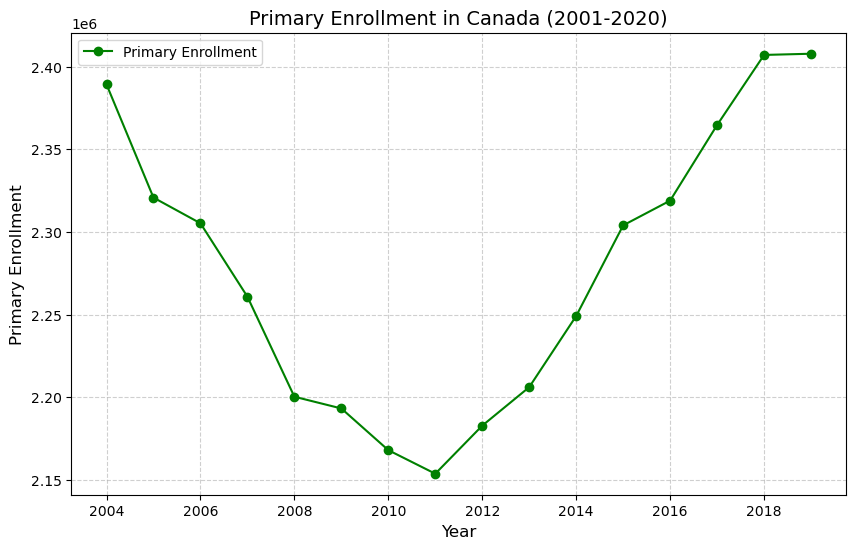

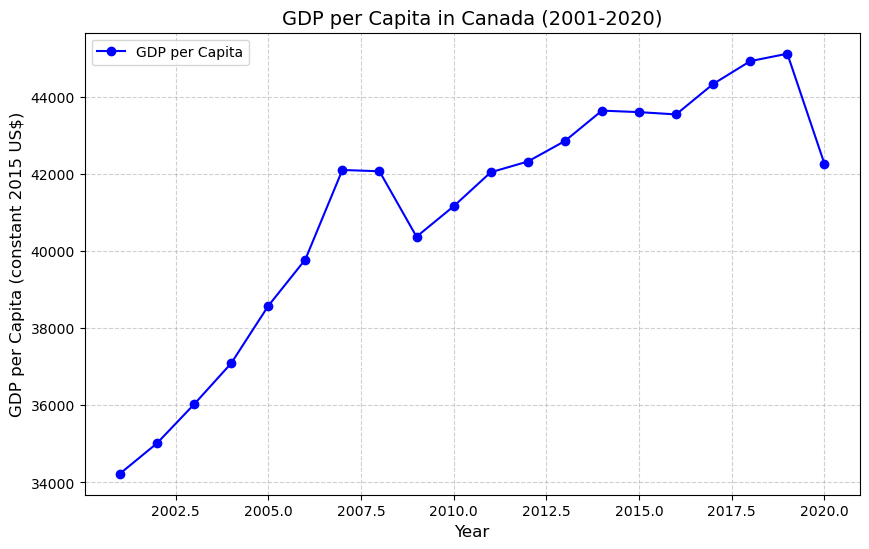

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File paths (replace with actual file paths)
enrollment_file = 'API_SE.PRM.ENRL_DS2_en_csv_v2_4538564.csv'
gdp_file = 'WDIData_Canada.csv'

# Loading the datasets
enrollment_data = pd.read_csv(enrollment_file, skiprows=4)  # Skip metadata rows
gdp_data = pd.read_csv(gdp_file)

# Step 1: Filter enrollment data for Canada
enrollment_canada = enrollment_data[enrollment_data['Country Name'] == 'Canada']
enrollment_canada = enrollment_canada.loc[:, '2001':'2020'].T
enrollment_canada.reset_index(inplace=True)
enrollment_canada = enrollment_canada.iloc[:, [0, 1]]  # Retain only relevant columns
enrollment_canada.columns = ['Year', 'Primary Enrollment']
enrollment_canada['Year'] = enrollment_canada['Year'].astype(int)

# Step 2: Extract GDP per capita data for Canada
gdp_canada = gdp_data[
    (gdp_data['Country Name'] == 'Canada') &
    (gdp_data['Indicator Name'] == 'GDP per capita (constant 2015 US$)')
]
gdp_canada = gdp_canada.loc[:, '2001':'2020'].T
gdp_canada.reset_index(inplace=True)
gdp_canada.columns = ['Year', 'GDP per Capita']
gdp_canada['Year'] = gdp_canada['Year'].astype(int)

# Step 3: Merge the datasets on 'Year'
merged_data = pd.merge(enrollment_canada, gdp_canada, on='Year', how='inner')

# Step 4: Handle missing values using NumPy
merged_data['Primary Enrollment'] = merged_data['Primary Enrollment'].replace(0, np.nan)
merged_data['Primary Enrollment'] = merged_data['Primary Enrollment'].interpolate(method='linear')

# Step 5: Create a scatter plot to show the correlation

# Step 4: Plot enrollment data
plt.figure(figsize=(10, 6))
plt.plot(enrollment_canada['Year'], enrollment_canada['Primary Enrollment'], color='green', marker='o', label='Primary Enrollment')
plt.title('Primary Enrollment in Canada (2001-2020)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Primary Enrollment', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Step 5: Plot GDP data
plt.figure(figsize=(10, 6))
plt.plot(gdp_canada['Year'], gdp_canada['GDP per Capita'], color='blue', marker='o', label='GDP per Capita')
plt.title('GDP per Capita in Canada (2001-2020)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP per Capita (constant 2015 US$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()